# Chest X-Ray Pneumonia Detection

Binary classification of chest X-ray images (Normal vs Pneumonia) using a custom CNN trained with data augmentation and class-weight balancing.

**Dataset:** [Labeled Chest X-Ray Images](https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images)

**Notebook structure:**
1. Setup & Data Download
2. Data Preparation
3. Dataset Exploration & EDA
4. Preprocessing & Augmentation
5. Model Building
6. Training
7. Evaluation
8. Results Summary

In [15]:
import os
import shutil
import random
import pathlib
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Model building
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Image processing
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from skimage import io
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.13.2


## 1. Setup & Data Download

In [16]:
# Set up Kaggle credentials
# Option A – Colab: upload kaggle.json manually
# from google.colab import files; files.upload()

# Option B – already have kaggle.json at ~/.kaggle/
import os, shutil

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

if os.path.exists("kaggle.json") and not os.path.exists(os.path.join(kaggle_dir, "kaggle.json")):
    shutil.copy("kaggle.json", kaggle_dir)

kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
if os.path.exists(kaggle_json_path):
    os.chmod(kaggle_json_path, 0o600)
    print("kaggle.json ready.")
else:
    print("kaggle.json not found — download may fail.")

kaggle.json ready.


In [17]:
# Download and extract dataset
# Skip if already extracted
if not os.path.exists("chest_xray"):
    os.system("kaggle datasets download -d tolgadincer/labeled-chest-xray-images")
    import zipfile
    with zipfile.ZipFile("labeled-chest-xray-images.zip", "r") as z:
        z.extractall(".")
    print("Dataset extracted.")
else:
    print("Dataset already exists, skipping download.")

Dataset already exists, skipping download.


## 2. Data Preparation

In [18]:
# Merge original train/ and test/ into a single dataset/ folder
# so we can re-split with stratification ourselves
train_dir    = "chest_xray/train"
test_dir     = "chest_xray/test"
combined_dir = "chest_xray/dataset"

if not os.path.exists(combined_dir):
    os.makedirs(combined_dir, exist_ok=True)
    for src_dir in [train_dir, test_dir]:
        for category in os.listdir(src_dir):
            cat_path = os.path.join(src_dir, category)
            if os.path.isdir(cat_path):
                shutil.copytree(cat_path,
                                os.path.join(combined_dir, category),
                                dirs_exist_ok=True)
    print("Combined dataset created.")
else:
    print("Combined dataset already exists, skipping.")

# Quick count
for cls in sorted(os.listdir(combined_dir)):
    n = len(os.listdir(os.path.join(combined_dir, cls)))
    print(f"  {cls}: {n} images")

Combined dataset already exists, skipping.
  NORMAL: 1583 images
  NORMAL_augmented: 2000 images
  PNEUMONIA: 4273 images


## 3. Dataset Exploration & EDA

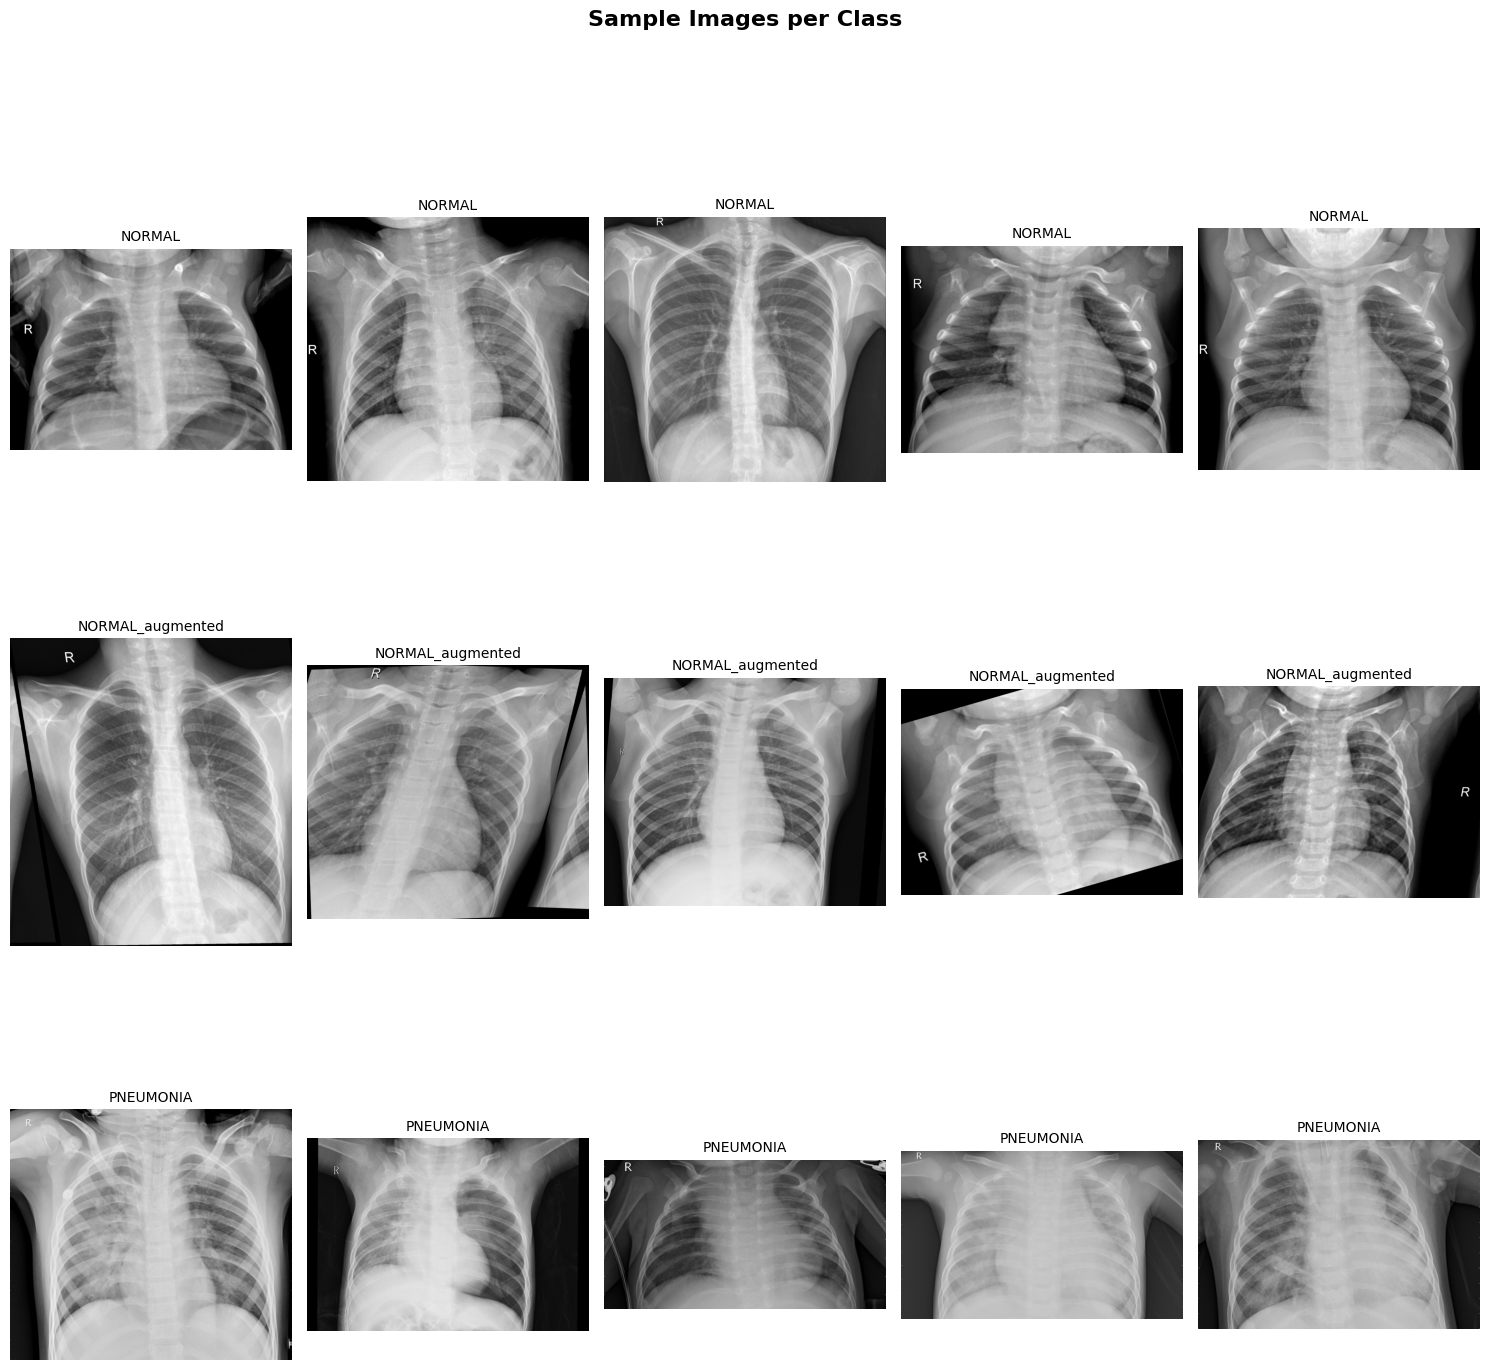

In [19]:
# Display 5 random sample images per class
path_sub = "chest_xray/dataset/"
lung_image = {cls: os.listdir(os.path.join(path_sub, cls))
              for cls in os.listdir(path_sub) if os.path.isdir(os.path.join(path_sub, cls))}

classes = sorted(lung_image.keys())
fig, axs = plt.subplots(len(classes), 5, figsize=(15, 5 * len(classes)))
fig.suptitle("Sample Images per Class", fontsize=16, fontweight='bold', y=1.01)

for i, class_name in enumerate(classes):
    samples = np.random.choice(lung_image[class_name], 5, replace=False)
    for j, img_name in enumerate(samples):
        img = Image.open(os.path.join(path_sub, class_name, img_name)).convert("L")
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set_title(class_name, fontsize=10)
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

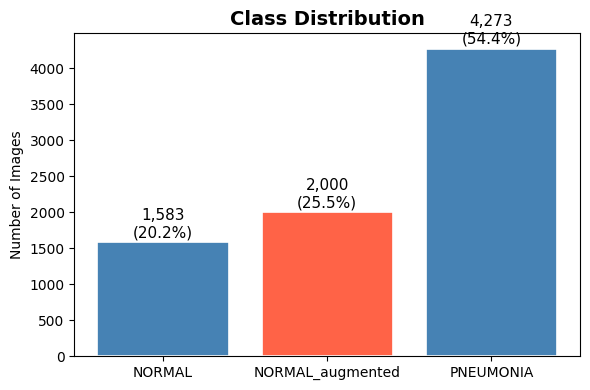

Imbalance ratio: 2.70x — class weights will be applied during training.


In [20]:
# Class distribution
class_counts = {cls: len(files) for cls, files in lung_image.items()}
total = sum(class_counts.values())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.2)
ax.set_title("Class Distribution", fontsize=14, fontweight='bold')
ax.set_ylabel("Number of Images")
for bar, (cls, cnt) in zip(bars, class_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{cnt:,}\n({cnt/total*100:.1f}%)', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

imbalance_ratio = max(class_counts.values()) / min(class_counts.values())
print(f"Imbalance ratio: {imbalance_ratio:.2f}x — class weights will be applied during training.")

NORMAL — W: 976–2844px, H: 680–2570px
NORMAL_augmented — W: 1056–2916px, H: 767–2628px


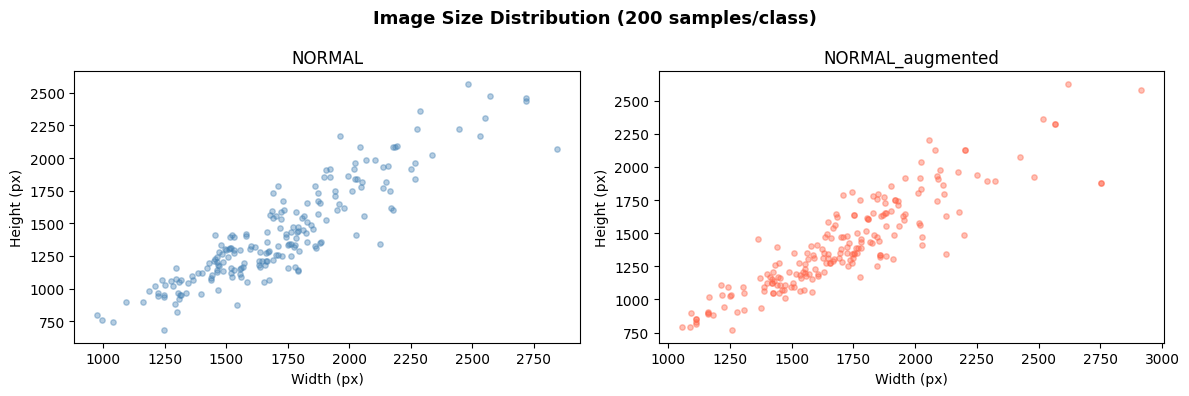

In [21]:
# Image size distribution (sample 200 images per class)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Image Size Distribution (200 samples/class)", fontsize=13, fontweight='bold')

for ax, cls in zip(axes, classes):
    samples = np.random.choice(lung_image[cls], min(200, len(lung_image[cls])), replace=False)
    widths, heights = [], []
    for name in samples:
        img = Image.open(os.path.join(path_sub, cls, name))
        w, h = img.size
        widths.append(w)
        heights.append(h)
    ax.scatter(widths, heights, alpha=0.4, s=15, color='steelblue' if cls == 'NORMAL' else 'tomato')
    ax.set_title(cls)
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")
    print(f"{cls} — W: {np.min(widths)}–{np.max(widths)}px, H: {np.min(heights)}–{np.max(heights)}px")

plt.tight_layout()
plt.show()

KeyError: 'NORMAL_augmented'

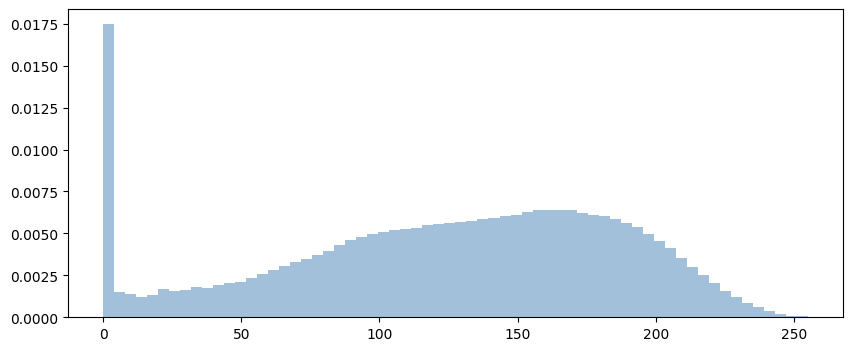

In [23]:
# Pixel intensity histogram per class (sample 100 images/class)
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'NORMAL': 'steelblue', 'PNEUMONIA': 'tomato'}

for cls in classes:
    samples = np.random.choice(lung_image[cls], min(100, len(lung_image[cls])), replace=False)
    pixel_vals = []
    for name in samples:
        img = np.array(Image.open(os.path.join(path_sub, cls, name)).convert("L").resize((150, 150)))
        pixel_vals.extend(img.flatten().tolist())
    ax.hist(pixel_vals, bins=64, alpha=0.5, label=cls, color=colors[cls], density=True)

ax.set_title("Pixel Intensity Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Pixel Value (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Preprocessing & Augmentation

In [24]:
# ── Augmentation Functions ───────────────────────────────────────────────────

def anticlockwise_rotation(image):
    return rotate(image, np.random.randint(1, 30))

def clockwise_rotation(image):
    return rotate(image, -np.random.randint(1, 30))

def warp_shift(image):
    transform = AffineTransform(translation=(np.random.randint(-50, 50),
                                              np.random.randint(-50, 50)))
    return warp(image, transform, mode="wrap")

def blur_image(image):
    img_u8 = img_as_ubyte(image) if image.dtype != np.uint8 else image
    blurred = cv2.GaussianBlur(img_u8, (9, 9), 0)
    return blurred.astype(np.float64) / 255.0

def add_brightness(image):
    return adjust_gamma(image, gamma=np.random.uniform(0.5, 1.5))

def flip_left_right(image):
    return np.fliplr(image)

def sheared(image):
    transform = AffineTransform(shear=np.random.uniform(-0.3, 0.3))
    return warp(image, transform, mode="wrap")

TRANSFORMATIONS = {
    'rotate_ccw':  anticlockwise_rotation,
    'rotate_cw':   clockwise_rotation,
    'warp_shift':  warp_shift,
    'blur':        blur_image,
    'brightness':  add_brightness,
    'flip_lr':     flip_left_right,
    'shear':       sheared,
}

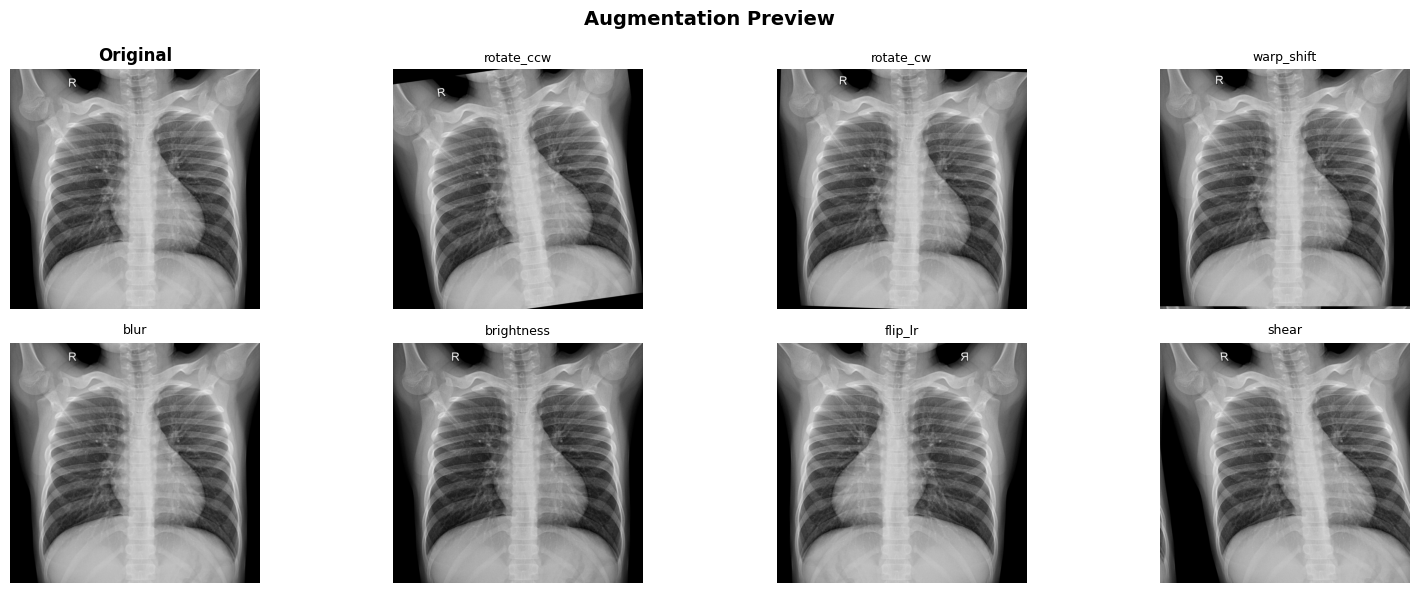

In [25]:
# Visualise augmentation effects on one sample image
sample_path = os.path.join(path_sub, "NORMAL", lung_image["NORMAL"][0])
original = io.imread(sample_path)
if original.ndim == 2:
    original = np.stack([original]*3, axis=-1)
if original.dtype != np.uint8:
    original = (original * 255).clip(0, 255).astype(np.uint8)
orig_float = original.astype(np.float64) / 255.0

n_transforms = len(TRANSFORMATIONS)
fig, axes = plt.subplots(2, (n_transforms + 2) // 2, figsize=(16, 6))
axes = axes.flatten()
axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

for idx, (name, fn) in enumerate(TRANSFORMATIONS.items(), start=1):
    try:
        aug = fn(orig_float.copy())
        aug_u8 = (np.clip(aug, 0, 1) * 255).astype(np.uint8)
        axes[idx].imshow(aug_u8, cmap='gray')
    except Exception as e:
        axes[idx].text(0.5, 0.5, str(e), ha='center')
    axes[idx].set_title(name, fontsize=9)
    axes[idx].axis('off')

for ax in axes[n_transforms+1:]:
    ax.axis('off')

fig.suptitle("Augmentation Preview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Generate augmented images for NORMAL class to balance dataset
images_path    = "chest_xray/dataset/NORMAL"
augmented_path = "chest_xray/dataset/NORMAL_augmented"
images_to_generate = 2000

if len(os.listdir(augmented_path)) >= images_to_generate if os.path.exists(augmented_path) else False:
    print(f"Augmented images already exist ({images_to_generate}), skipping.")
else:
    os.makedirs(augmented_path, exist_ok=True)
    images = [os.path.join(images_path, f) for f in os.listdir(images_path)]
    i = 1
    while i <= images_to_generate:
        image_path = random.choice(images)
        try:
            original_image = io.imread(image_path)
            if original_image.ndim == 2:
                original_image = np.stack([original_image]*3, axis=-1)
            elif original_image.ndim == 3 and original_image.shape[2] == 4:
                original_image = original_image[:, :, :3]
            if original_image.dtype != np.uint8:
                original_image = (original_image * 255).clip(0, 255).astype(np.uint8)

            img_float = original_image.astype(np.float64) / 255.0
            n_aug = random.randint(1, 3)
            for _ in range(n_aug):
                fn = random.choice(list(TRANSFORMATIONS.values()))
                img_float = fn(img_float)
                img_float = np.clip(img_float, 0, 1)

            img_out = (img_float * 255).astype(np.uint8)
            cv2.imwrite(f"{augmented_path}/aug_{i:05d}.jpg", img_out)
            i += 1
            if i % 500 == 0:
                print(f"  {i}/{images_to_generate}")
        except Exception as e:
            pass
    print(f"Done: {images_to_generate} augmented images saved.")

Augmented images already exist (2000), skipping.


### 4.2 Data Splitting

In [27]:
# Collect all image paths + labels into a DataFrame
lung_path = "chest_xray/dataset/"

records = []
for root, _, files in os.walk(lung_path):
    label = os.path.basename(root)
    for fname in files:
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            records.append({'path': os.path.join(root, fname),
                            'file_name': fname,
                            'labels': label})

df_all_raw = pd.DataFrame(records)
print("Total images:", len(df_all_raw))
print(df_all_raw['labels'].value_counts())

Total images: 7856
labels
PNEUMONIA           4273
NORMAL_augmented    2000
NORMAL              1583
Name: count, dtype: int64


In [28]:
# Stratified 80/20 split
X = df_all_raw['path']
y = df_all_raw['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

df_tr = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_te = pd.DataFrame({'path': X_test,  'labels': y_test,  'set': 'test'})
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print("Split summary:")
print(df_all.groupby(['set', 'labels']).size().to_string())

Split summary:
set    labels          
test   NORMAL               317
       NORMAL_augmented     400
       PNEUMONIA            855
train  NORMAL              1266
       NORMAL_augmented    1600
       PNEUMONIA           3418


In [29]:
import importlib
import tqdm
importlib.reload(tqdm)
from tqdm import tqdm as tq

In [30]:
for _, row in tq(df_all.iterrows(), total=len(df_all)):
    file_name = os.path.basename(row['path'])
    dest_dir = os.path.join(dataset_path, row['set'], row['labels'])
    os.makedirs(dest_dir, exist_ok=True)
    dest_file = os.path.join(dest_dir, file_name)
    if not os.path.exists(dest_file):
        shutil.copy2(row['path'], dest_file)
print("Dataset-Final created.")

100%|██████████| 7856/7856 [00:02<00:00, 2707.06it/s]

Dataset-Final created.


In [32]:
# Copy split files to Dataset-Final/train/ and Dataset-Final/test/
datasource_path = "chest_xray/dataset/"
dataset_path    = "Dataset-Final/"

if not os.path.exists(dataset_path):
    for _, row in tq(df_all.iterrows(), total=len(df_all)):
        dest_dir = os.path.join(dataset_path, row['set'], row['labels'])
        os.makedirs(dest_dir, exist_ok=True)
        dest_file = os.path.join(dest_dir, row['file_name'])
        if not os.path.exists(dest_file):
            shutil.copy2(row['path'], dest_file)
    print("Dataset-Final created.")
else:
    print("Dataset-Final already exists, skipping copy.")

TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR  = "Dataset-Final/test/"

for split, d in [("Train", TRAIN_DIR), ("Test", TEST_DIR)]:
    for cls in sorted(os.listdir(d)):
        n = len(os.listdir(os.path.join(d, cls)))
        print(f"  {split}/{cls}: {n}")

Dataset-Final already exists, skipping copy.
  Train/NORMAL: 1266
  Train/NORMAL_augmented: 1600
  Train/PNEUMONIA: 3418
  Test/NORMAL: 317
  Test/NORMAL_augmented: 400
  Test/PNEUMONIA: 855


In [33]:
print(df_all.columns.tolist())
print(df_all.head(2))

['path', 'labels', 'set']
                                                path            labels    set
0  chest_xray/dataset/PNEUMONIA\BACTERIA-8028911-...         PNEUMONIA  train
1  chest_xray/dataset/NORMAL_augmented\aug_01153.jpg  NORMAL_augmented  train


In [34]:
# ImageDataGenerators
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR  = "Dataset-Final/test/"
IMG_SIZE  = (150, 150)
BATCH     = 32

datagen      = ImageDataGenerator(rescale=1/255., validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1/255.)

train_generator = datagen.flow_from_directory(
    TRAIN_DIR, batch_size=BATCH, target_size=IMG_SIZE,
    color_mode="grayscale", class_mode='binary',
    subset='training', shuffle=True)

val_generator = datagen.flow_from_directory(
    TRAIN_DIR, batch_size=BATCH, target_size=IMG_SIZE,
    color_mode="grayscale", class_mode='binary',
    subset='validation', shuffle=False)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, batch_size=1, target_size=IMG_SIZE,
    color_mode="grayscale", class_mode='binary', shuffle=False)

print("\nClass indices:", train_generator.class_indices)

Found 5028 images belonging to 3 classes.
Found 1256 images belonging to 3 classes.
Found 1572 images belonging to 3 classes.

Class indices: {'NORMAL': 0, 'NORMAL_augmented': 1, 'PNEUMONIA': 2}


## 5. Model Building

In [35]:
# Compute class weights to handle imbalance
labels_array = train_generator.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)
# 0=NORMAL, 1=PNEUMONIA (based on alphabetical order from flow_from_directory)

Class weights: {0: np.float64(1.6544916090819348), 1: np.float64(1.309375), 2: np.float64(0.6127970749542961)}


In [36]:
# Custom CNN architecture
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 1)),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Block 4
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Classifier head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
], name="ChestXRay_CNN")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

c:\Users\akbar\VSCode Project\chest-xray\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ChestXRay_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,929,153 (11.17 MB)

 Trainable params: 2,928,449 (11.17 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Training

In [37]:
import os
os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/logs", exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        filepath='outputs/models/best_model.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1),
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.2543 - auc: 0.6357 - loss: -28898.4504
Epoch 1: val_auc improved from None to 0.50000, saving model to outputs/models/best_model.keras

Epoch 1: finished saving model to outputs/models/best_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 145s 903ms/step - accuracy: 0.2572 - auc: 0.6644 - loss: -148522.2344 - val_accuracy: 0.2548 - val_auc: 0.5000 - val_loss: -715339.2500 - learning_rate: 0.0010
Epoch 2/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.2667 - auc: 0.7449 - loss: -2601005.2975
Epoch 2: val_auc did not improve from 0.50000
158/158 ━━━━━━━━━━━━━━━━━━━━ 102s 642ms/step - accuracy: 0.2651 - auc: 0.7467 - loss: -5719973.0000 - val_accuracy: 0.2548 - val_auc: 0.5000 - val_loss: -16156871.0000 - learning_rate: 0.0010
Epoch 3/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.2656 - auc: 0.7431 - loss: -26822229.4684
Epoch 3: val_auc did not improve from 0.50000
158/158 ━━━━━━━━━━━━━━━━━━━━ 103s 649m

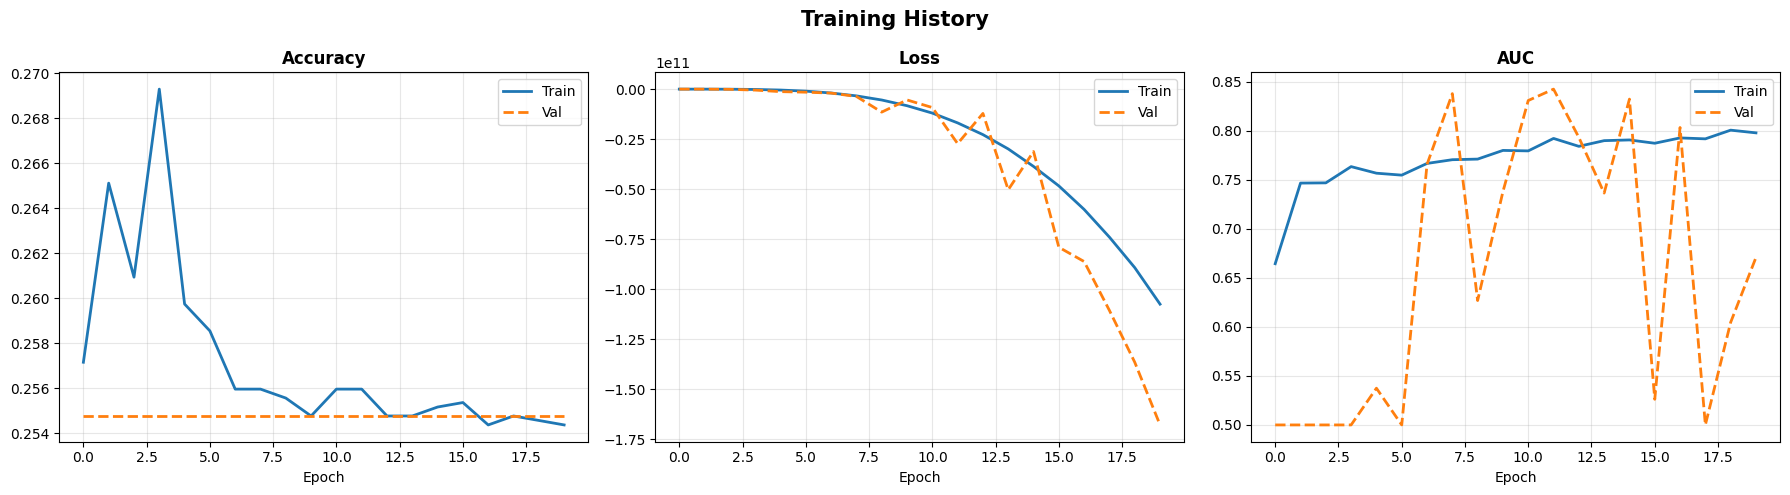

Best epoch: 12
  val_accuracy : 0.2548
  val_auc      : 0.8425
  val_loss     : -27245082624.0000


In [38]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=15, fontweight='bold')

metrics = [
    ('accuracy',   'val_accuracy',   'Accuracy'),
    ('loss',       'val_loss',       'Loss'),
    ('auc',        'val_auc',        'AUC'),
]

for ax, (train_key, val_key, title) in zip(axes, metrics):
    ax.plot(history.history[train_key], label='Train', linewidth=2)
    ax.plot(history.history[val_key],   label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = np.argmax(history.history['val_auc'])
print(f"Best epoch: {best_epoch+1}")
print(f"  val_accuracy : {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"  val_auc      : {history.history['val_auc'][best_epoch]:.4f}")
print(f"  val_loss     : {history.history['val_loss'][best_epoch]:.4f}")

## 7. Evaluation

In [39]:
# Load best checkpoint and evaluate on test set
from tensorflow.keras.models import load_model

best_model = load_model("outputs/models/best_model.keras")
test_generator.reset()

probs = best_model.predict(test_generator, verbose=1)
preds = (probs > 0.5).astype(int).flatten()
true  = test_generator.classes

# Confusion matrix
cm = confusion_matrix(true, preds)
cm_df = pd.DataFrame(cm,
    index=["Actual Normal", "Actual Pneumonia"],
    columns=["Pred Normal", "Pred Pneumonia"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'size': 14})
ax.set_title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report
print("\n" + "="*55)
print(classification_report(true, preds,
      target_names=['Normal', 'Pneumonia'], digits=4))

1572/1572 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step


ValueError: Shape of passed values is (3, 3), indices imply (2, 2)

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(true, probs.flatten())
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Test Set", fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Test AUC: {roc_auc:.4f}")

In [ ]:
# Save final model
model.save("outputs/models/chest_xray_cnn_final.keras")
print("Model saved to outputs/models/chest_xray_cnn_final.keras")

## 8. Results Summary

In [ ]:
# Auto-generate results summary from classification report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

acc  = accuracy_score(true, preds)
prec = precision_score(true, preds)
rec  = recall_score(true, preds)
f1   = f1_score(true, preds)

summary = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Precision (Pneumonia)', 'Recall (Pneumonia)',
               'F1-Score (Pneumonia)', 'ROC-AUC'],
    'Value':  [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}',
               f'{f1:.4f}', f'{roc_auc:.4f}']
})

print(summary.to_markdown(index=False))
print(f"\nBest epoch: {best_epoch+1} / {len(history.history['loss'])}")
print(f"Early stopping: {'Yes' if len(history.history['loss']) < 30 else 'No'}")